# Image Classification using the Digits Dataset
### Beginner ML Lab

## Learning Objectives
- Understand image classification
- Explore the Digits dataset
- Visualize handwritten digits
- Train a KNN classifier
- Evaluate using Accuracy, Confusion Matrix and Classification Report
- Tune the hyperparameter k
- Observe misclassified images
- Understand why Deep Learning became important


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


## Step 1: Load the Dataset

In [ ]:
digits = load_digits()

print(digits.keys())
print("Images:", digits.images.shape)
print("Flattened Data:", digits.data.shape)
print("Labels:", digits.target.shape)


dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Images: (1797, 8, 8)
Flattened Data: (1797, 64)
Labels: (1797,)


## Step 2: Visualize Some Digits

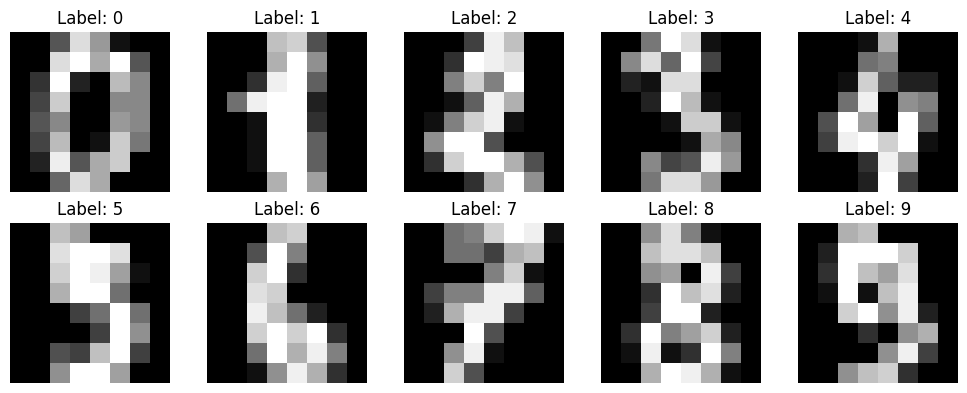

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Step 3: Images as Numbers

In [ ]:
print(digits.images[0])

X = digits.data
y = digits.target

print("Feature Matrix:", X.shape)
print("Target:", y.shape)


[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Feature Matrix: (1797, 64)
Target: (1797,)


## Step 4: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)


## Step 5: Train KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)


KNeighborsClassifier(n_neighbors=3)

## Step 6: Prediction

In [ ]:
y_pred = knn.predict(X_test)
print(y_pred[:10])


[6 9 3 7 2 1 5 2 5 2]


## Step 7: Evaluation

Accuracy: 0.9833333333333333


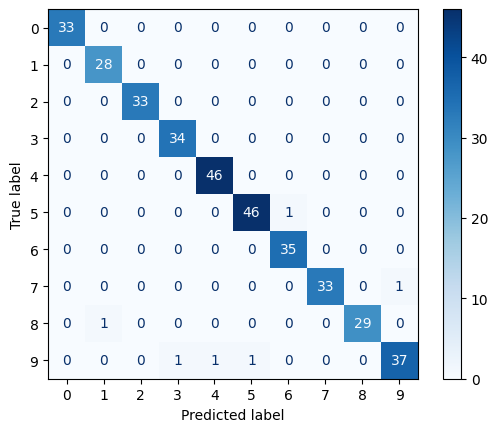

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.97      0.98        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [ ]:
print("Accuracy:", accuracy_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

print(classification_report(y_test,y_pred))


## Step 8: Hyperparameter Tuning

   k  Accuracy
0  1  0.977778
1  3  0.983333
2  5  0.986111
3  7  0.988889
4  9  0.980556


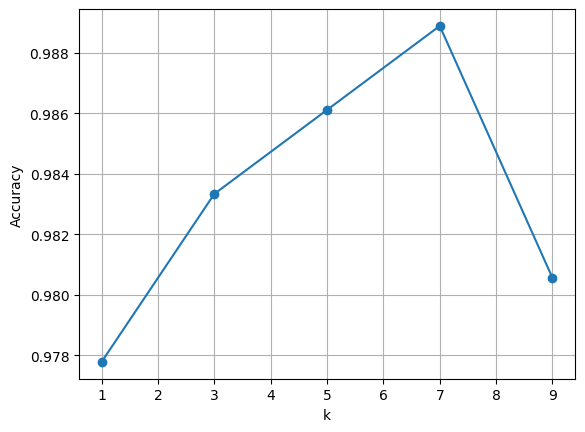

In [ ]:
results=[]
for k in [1,3,5,7,9]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append([k,acc])

results = pd.DataFrame(results, columns=['k','Accuracy'])
print(results)

plt.plot(results['k'],results['Accuracy'],marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


## Step 9: Misclassified Images

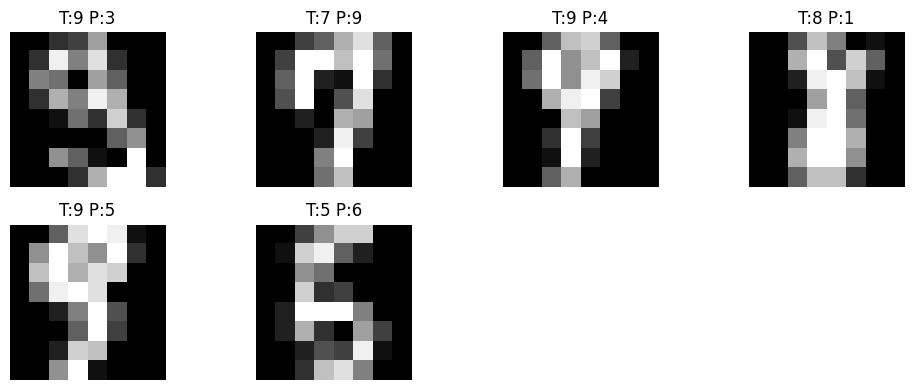

In [ ]:
wrong = np.where(y_pred!=y_test)[0]

plt.figure(figsize=(10,4))
for i,idx in enumerate(wrong[:8]):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[idx].reshape(8,8), cmap='gray')
    plt.title(f'T:{y_test[idx]} P:{y_pred[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


## Step 10: Predict a New Digit

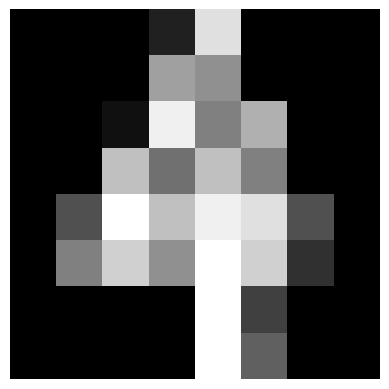

Predicted: 4
Actual: 4


In [ ]:
sample = X_test[20].reshape(1,-1)

plt.imshow(sample.reshape(8,8), cmap='gray')
plt.axis('off')
plt.show()

print("Predicted:", knn.predict(sample)[0])
print("Actual:", y_test[20])


# Looking Ahead

Today we used a traditional Machine Learning algorithm (KNN).

Modern datasets contain much larger images (e.g. 28×28 MNIST, or even 224×224 color images). For these problems, **Deep Learning** models such as **Convolutional Neural Networks (CNNs)** perform much better because they automatically learn useful image features.


# Practice

1. Display the first 20 images.
2. Try k = 11, 13, 15.
3. Find the best value of k.
4. Count the number of incorrect predictions.
5. Display five correctly classified images.
6. Read about the MNIST dataset and compare it with the Digits dataset.
